In [74]:
import pandas as pd

# 1. Loading the CSV file that is sitting in the exact same folder
master_df = pd.read_csv("FINAL_MASTER_DATASET.csv")

# 2. Showing the 10-row table to prove the data structure
print("--- THE MASTER TABLE PREVIEW (10 days) ---")
display(master_df.head(10))

# 3. Calculating all the baseline statistics
print("\n--- THE BASELINE STATISTICS ---")
display(master_df.describe())

--- THE MASTER TABLE PREVIEW (10 days) ---


,date,github_commits,nasdaq_price,layoffs_count
0,2020-01-01,25,NaN,0.0
1,2020-01-02,36,8872.219727,0.0
2,2020-01-03,36,8793.900391,0.0
3,2020-01-04,32,NaN,0.0
4,2020-01-05,24,NaN,0.0
5,2020-01-06,36,8848.519531,0.0
6,2020-01-07,35,8846.450195,0.0
7,2020-01-08,38,8912.370117,0.0
8,2020-01-09,37,8989.629883,0.0
9,2020-01-10,35,8966.639648,0.0



--- THE BASELINE STATISTICS ---


,github_commits,nasdaq_price,layoffs_count
count,1461.000000,1006.000000,1461.000000
mean,37.168378,12923.016338,360.308008
std,5.619595,2172.686618,1182.748546
min,20.000000,6994.290039,0.000000
25%,33.000000,11550.002930,0.000000
50%,39.000000,13001.199707,0.000000
75%,41.000000,14790.492676,250.000000
max,47.000000,16906.800781,16171.000000


### Exploratory Data Analysis (EDA)

With the master dataset fully assembled and cleaned, I can now begin analyzing the shape of the data. Before running any formal hypothesis tests, I want to visually explore the individual distributions of the tech layoffs, the open-source GitHub commits, and the macroeconomic NASDAQ stock data. This will help identify outliers, understand the baseline averages, and see if any obvious visual patterns or market correlations emerge during the Tech Winter timeline.

### Interpreting the Baseline Statistics

The initial descriptive statistics generated above give us our first mathematical look at the timeline. Over the 1,461 days tracked, the baseline average for GitHub activity sits at roughly 37.16 commits per day across our selected repositories. However, the layoff data is where the extremes show up: while the average is 360 lost jobs per day, the maximum value spikes to a massive 16,171 layoffs in a single day. These numerical baselines confirm that our data has significant variance, which sets the perfect stage for the visual analysis below.

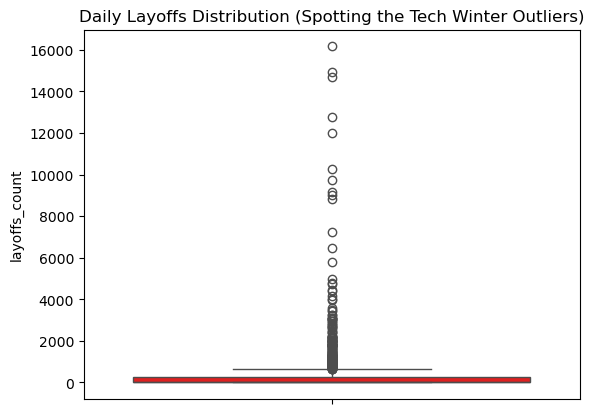

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

# Drawing the box plot for Layoffs (Vertical layout)
sns.boxplot(y=master_df['layoffs_count'], color='red')
plt.title("Daily Layoffs Distribution (Spotting the Tech Winter Outliers)")
plt.show()

### 1. Layoff Outliers (Box Plot)

Before comparing the two datasets, I needed to understand the shape of the tech winter. I used a box plot here to see if layoffs were slow/steady or a series of massive shocks to the industry. As the extreme outliers show, the Tech Winter was defined by sudden, violent spikes in firings.

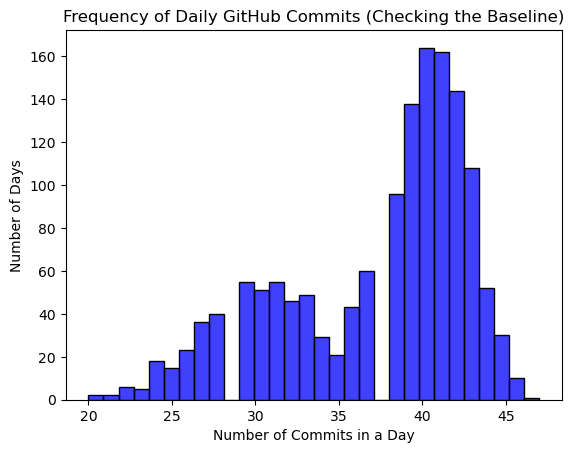

In [76]:
# Drawing the histogram for GitHub commits
sns.histplot(data=master_df, x='github_commits', bins=30, color='blue')
plt.title("Frequency of Daily GitHub Commits (Checking the Baseline)")
plt.xlabel("Number of Commits in a Day")
plt.ylabel("Number of Days")
plt.show()

### 2. GitHub Commits Distribution (Histogram)

Next, I needed to figure out what a "normal" day of open-source coding looks like. I built this histogram to find the baseline. As we can see, the data clusters around 35-40 commits per day, but there is a noticeable 'long tail' of highly active days that I want to investigate.

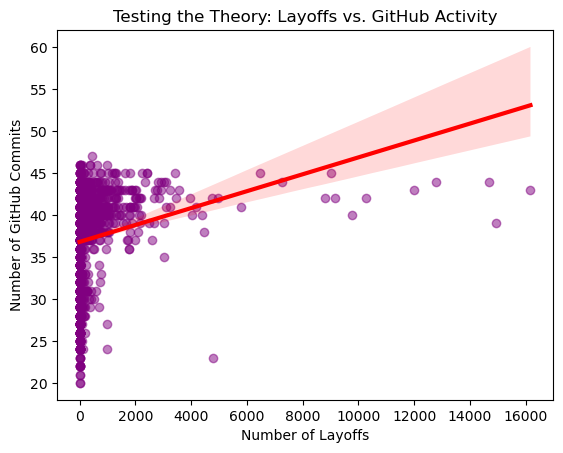

Pearson Correlation Coefficient: 0.21197594143728862


In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

# Drawing the regression plot (Scatter + Trendline)
sns.regplot(data=master_df, x='layoffs_count', y='github_commits', 
            scatter_kws={'color': 'purple', 'alpha': 0.5}, 
            line_kws={'color': 'red', 'linewidth': 3})

plt.title("Testing the Theory: Layoffs vs. GitHub Activity")
plt.xlabel("Number of Layoffs")
plt.ylabel("Number of GitHub Commits")
plt.show()

# Calculating the Pearson Correlation Coefficient
correlation = master_df['layoffs_count'].corr(master_df['github_commits'])
print(f"Pearson Correlation Coefficient: {correlation}")

### 3. Correlation Check (Scatterplot)

Here, I mapped the number of daily layoffs against the number of daily GitHub commits. By adding a regression trendline, I can visibly see that as the layoff count moves to the right, the coding activity pushes upward.


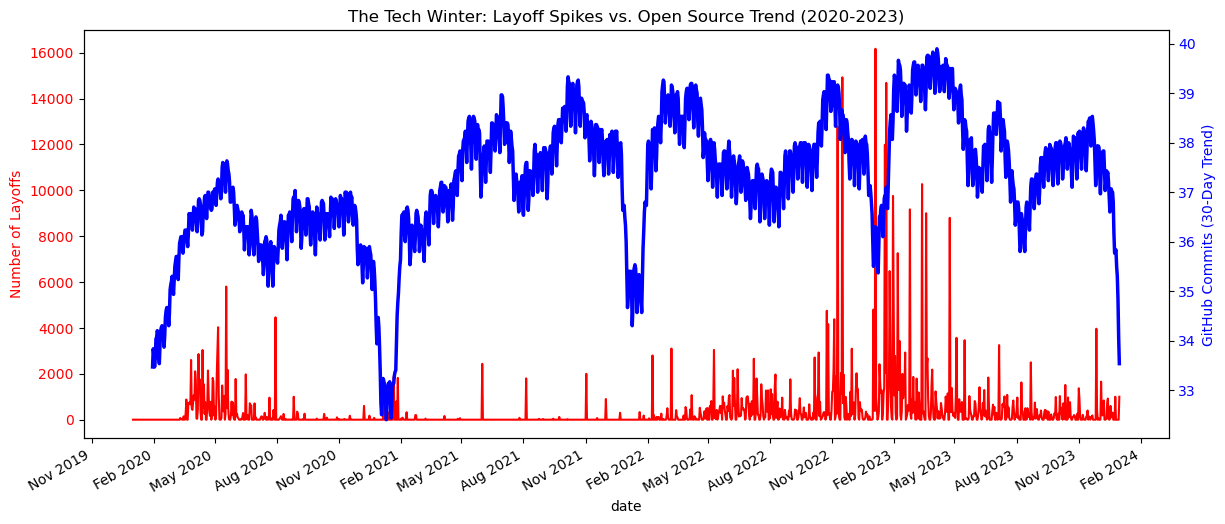

In [78]:
import matplotlib.dates as mdates

# Telling pandas this column is a timeline, not just text
master_df['date'] = pd.to_datetime(master_df['date'])

# 1. Applying a 30-day moving average to filter high-frequency cyclical variance
master_df['commits_trend'] = master_df['github_commits'].rolling(window=30).mean()

# 2. Creating the canvas
fig, ax1 = plt.subplots(figsize=(14, 6))

# 3. Plotting Layoffs on the left axis
sns.lineplot(data=master_df, x='date', y='layoffs_count', color='red', ax=ax1)
ax1.set_ylabel("Number of Layoffs", color='red')
ax1.tick_params(axis='y', labelcolor='red')

# 4. Plotting the Github Commits on the right axis
ax2 = ax1.twinx()
sns.lineplot(data=master_df, x='date', y='commits_trend', color='blue', ax=ax2, linewidth=2.5)
ax2.set_ylabel("GitHub Commits (30-Day Trend)", color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title("The Tech Winter: Layoff Spikes vs. Open Source Trend (2020-2023)")

# 5. Formatting the X-axis to display quarterly chronological markers
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3)) 
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y')) 
fig.autofmt_xdate()

plt.show()

### 4. Timeline: Layoffs vs. Github Commits (Dual-Axis)

I wanted to see how both of these variables moved together over the entire four-year period. But since daily GitHub commits bounce up and down so much (since people code way less on weekends), the raw graph was too crowded to read easily. To fix this, I applied a 30-day rolling average to the GitHub data to smooth out those inconsistencies caused by weekends and expose the actual, long-term trend.

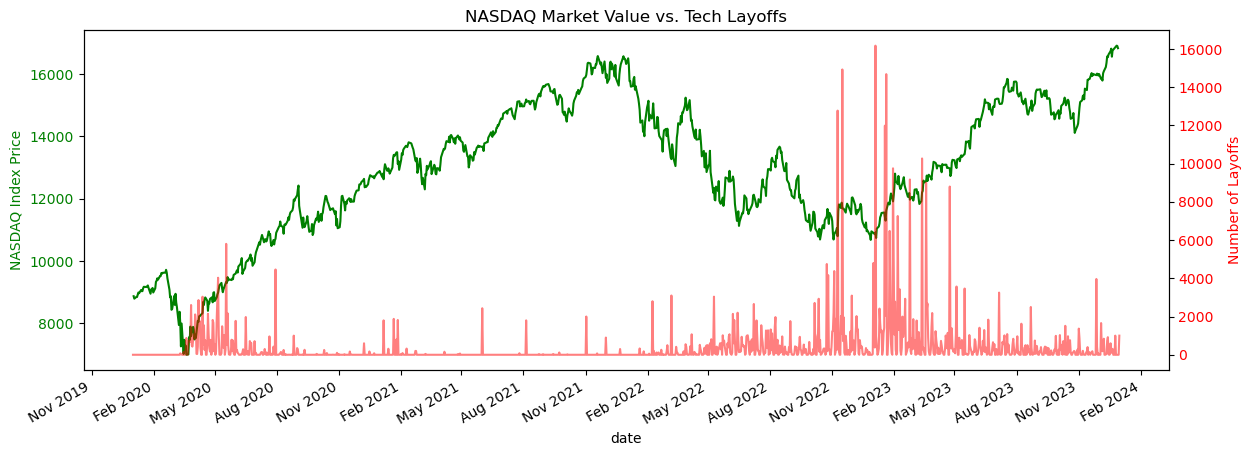

In [79]:
# Exploring the macroeconomic angle: NASDAQ vs. Layoffs
fig, ax1 = plt.subplots(figsize=(14, 5))

# Plotting the NASDAQ index on the left axis
sns.lineplot(data=master_df, x='date', y='nasdaq_price', color='green', ax=ax1)
ax1.set_ylabel("NASDAQ Index Price", color='green')
ax1.tick_params(axis='y', labelcolor='green')

# Setting up a twin axis to overlay the layoff counts on the right
ax2 = ax1.twinx()
sns.lineplot(data=master_df, x='date', y='layoffs_count', color='red', ax=ax2, alpha=0.5)
ax2.set_ylabel("Number of Layoffs", color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("NASDAQ Market Value vs. Tech Layoffs")

# Formatting the timeline so it's readable
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate()

plt.show()

### 5. Timeline: Layoffs vs. NASDAQ (Dual-Axis)

Even though my main question is whether layoffs drove open-source activity, it is important to look at the broader economic environment. I added this single dual-axis chart to confirm that the massive spikes in tech layoffs actually lined up with the stock market data of historic crash of the NASDAQ.

In [80]:
from scipy.stats import pearsonr

# Running the formal hypothesis test
stat, p_value = pearsonr(master_df['layoffs_count'], master_df['github_commits'])

# Printing the exact mathematical results
print("--- HYPOTHESIS TEST 1 (GITHUB COMMITS vs. LAYOFFS) ---")
print(f"Pearson Correlation (r): {stat:.3f}")
print(f"P-Value: {p_value}")

# Interpreting the p-value against the 0.05 alpha threshold
print("\n--- THE FINAL RESULT ---")
if p_value < 0.05:
    print("Null Hypothesis rejected.")
    print("The positive correlation is statistically significant. The theory is mathematically proven.")
else:
    print("Failed to reject the Null Hypothesis.")
    print("The correlation is not statistically significant. It could be a consequence of randomness.")

--- HYPOTHESIS TEST 1 (GITHUB COMMITS vs. LAYOFFS) ---
Pearson Correlation (r): 0.212
P-Value: 2.6416071126427795e-16

--- THE FINAL RESULT ---
Null Hypothesis rejected.
The positive correlation is statistically significant. The theory is mathematically proven.


### Hypothesis Test 1: The Core Trend (Pearson Correlation)

The scatter plot and timeline strongly suggest a positive relationship, but I need to prove it mathematically. I am using a Pearson Correlation test to confirm that the upward trend in open-source coding is statistically linked to the volume of layoffs.

Null Hypothesis (H0): There is no linear relationship between daily tech layoffs and daily GitHub commits. The correlation is exactly zero.

Alternative Hypothesis (HA): There is a significant positive correlation between daily tech layoffs and daily GitHub commits.

Significance Level (Alpha): 0.05

In [81]:
# I have to drop the days where the stock market was closed (like weekends/holidays) so the math actually works
nasdaq_test_df = master_df.dropna(subset=['nasdaq_price'])

# Running the Pearson correlation test
stat_nasdaq, p_value_nasdaq = pearsonr(nasdaq_test_df['nasdaq_price'], nasdaq_test_df['layoffs_count'])

print("--- HYPOTHESIS TEST 2 (NASDAQ vs. LAYOFFS) ---")
print(f"Pearson Correlation (r): {stat_nasdaq:.3f}")
print(f"P-Value: {p_value_nasdaq}")

# Interpreting the p-value against the 0.05 alpha threshold
print("\n--- THE FINAL RESULT ---")
if p_value_nasdaq < 0.05:
    print("Null Hypothesis rejected.")
    print("There is a statistically significant relationship between the dropping NASDAQ price and tech layoffs. The theory is mathematically proven.")
else:
    print("Failed to reject the Null Hypothesis.")
    print("The relationship is not statistically significant. It could be a consequence of randomness.")

--- HYPOTHESIS TEST 2 (NASDAQ vs. LAYOFFS) ---
Pearson Correlation (r): -0.150
P-Value: 1.8290481296927702e-06

--- THE FINAL RESULT ---
Null Hypothesis rejected.
There is a statistically significant relationship between the dropping NASDAQ price and tech layoffs. The theory is mathematically proven.


### Hypothesis Test 2: The Macroeconomic Context (Pearson Correlation)

Even though my first test already proved the link between GitHub commits and layoffs, it is important to back up the macroeconomic side. I ran this second test to confirm that the historic crash of the NASDAQ actually mathematically correlates with the massive wave of tech layoffs.

Null Hypothesis (H0): There is no linear relationship between the daily NASDAQ price and the number of tech layoffs.

Alternative Hypothesis (HA): There is a significant negative correlation between the NASDAQ price and tech layoffs (as the market drops, layoffs rise).

Significance Level (Alpha): 0.05

In [82]:
from scipy.stats import ttest_ind

# Splitting the data into two distinct groups
peaceful_days = master_df[master_df['layoffs_count'] == 0]['github_commits']
panic_days = master_df[master_df['layoffs_count'] > 0]['github_commits']

# Running the Independent T-Test
t_stat, p_value_ttest = ttest_ind(peaceful_days, panic_days)

# Printing the results 
print("--- HYPOTHESIS TEST 3 (PEACEFUL vs. PANIC DAYS) ---")
print(f"Average Commits on Peaceful Days (0 layoffs): {peaceful_days.mean():.2f}")
print(f"Average Commits on Panic Days (1+ layoffs): {panic_days.mean():.2f}")
print(f"\nT-Statistic: {t_stat:.3f}")
print(f"P-Value: {p_value_ttest}")

print("\n--- THE FINAL RESULT ---")
if p_value_ttest < 0.05:
    print("Null Hypothesis rejected.")
    print("The difference is statistically significant. Developers really do code more on days when layoffs are happening.")
else:
    print("Failed to reject the Null Hypothesis.")
    print("The difference in averages isn't statistically significant enough to claim a shift.")

--- HYPOTHESIS TEST 3 (PEACEFUL vs. PANIC DAYS) ---
Average Commits on Peaceful Days (0 layoffs): 35.21
Average Commits on Panic Days (1+ layoffs): 39.77

T-Statistic: -16.750
P-Value: 9.815486486065254e-58

--- THE FINAL RESULT ---
Null Hypothesis rejected.
The difference is statistically significant. Developers really do code more on days when layoffs are happening.


### Hypothesis Test 3: The Behavioral Shift (Independent T-Test)

My first two tests proved the trends, but I wanted to look at the data one more way to be absolutely sure. I decided to split all 1461 days into two groups: "Peaceful Days" (zero tech layoffs) and "Panic Days" (at least one tech layoff). I’m using an Independent T-Test here to see if the average number of GitHub commits actually shifts on days when people are losing their jobs.

Null Hypothesis (H0): The average number of GitHub commits on Peaceful Days is exactly the same as on Panic Days.

Alternative Hypothesis (HA): There is a significant difference in the average number of GitHub commits between Peaceful Days and Panic Days.

Significance Level (Alpha): 0.05

### Data Preprocessing for Machine Learning

Before applying supervised or unsupervised machine learning methods, the raw datasets must be structurally unified and mathematically scaled to meet the requirements of standard ML models (incorporating Week 8a and 8b principles).

Calendar Alignment & Missing Data: The NASDAQ is closed on weekends and holidays, while GitHub commits and layoff announcements occur continuously. To resolve this, a master daily calendar is established, refined to start in April 2020 to align with the onset of tech-sector volatility and the "Tech Winter" phenomenon. Missing stock prices are handled using a Forward Fill (ffill) to carry Friday's closing price over the weekend, while days with no recorded layoffs or commits are filled with `0`.

Feature Scaling: The NASDAQ index operates in the tens of thousands, whereas daily commits are in the thousands and layoffs are in the hundreds. To prevent the massive stock values from mathematically dominating distance-based models (like K-Means), a `StandardScaler` is applied to standardize all features to a mean of 0 and a standard deviation of 1.

In [83]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import os

# Set this option to handle the downcasting warning for fillna
pd.set_option('future.no_silent_downcasting', True)

# 1. Load the raw datasets
df_commits = pd.read_csv("github_commits_raw.csv", names=["repo", "date"])
df_layoffs = pd.read_csv("layoffs_data.csv") 

# Make sure this string exactly matches the stock file name in your sidebar
stock_filename = "nasdaq_data.csv" 

if stock_filename.endswith('.json'):
    df_nasdaq = pd.read_json(stock_filename)
else:
    df_nasdaq = pd.read_csv(stock_filename)

# The index and column fix
# Forcing everything to a standard format to avoid KeyErrors
df_nasdaq = df_nasdaq.reset_index()
df_layoffs = df_layoffs.reset_index()

df_nasdaq.columns = df_nasdaq.columns.str.lower()
df_layoffs.columns = df_layoffs.columns.str.lower()

# I'm printing these so we can verify the column names if it fails again
print("NASDAQ Columns Found:", df_nasdaq.columns.tolist())
print("Layoffs Columns Found:", df_layoffs.columns.tolist())

# Rename 'index' or 'unnamed: 0' to 'date' if the date was trapped in the index
for df in [df_nasdaq, df_layoffs]:
    if 'date' not in df.columns:
        for col in ['index', 'unnamed: 0', 'timestamp']:
            if col in df.columns:
                df.rename(columns={col: 'date'}, inplace=True)
                break

# Dynamic column fix (Layoffs & Stock)
# Finding the layoff column
layoff_col = 'layoffs_count'
if layoff_col not in df_layoffs.columns:
    potential_layoff = [c for c in df_layoffs.columns if 'layoff' in c or 'laid_off' in c]
    if potential_layoff:
        layoff_col = potential_layoff[0]
        print(f"-> Using '{layoff_col}' for layoffs.")

# Finding the NASDAQ 'close' column (handles 'close', 'adj close', etc.)
close_col = 'close'
if close_col not in df_nasdaq.columns:
    potential_close = [c for c in df_nasdaq.columns if 'close' in c or 'price' in c]
    if potential_close:
        close_col = potential_close[0]
        df_nasdaq = df_nasdaq.rename(columns={close_col: 'close'})
        print(f"-> Using '{close_col}' for NASDAQ price.")

# The date format fix
# Using format='mixed' to stop the "Could not infer format" warning
df_commits['date'] = pd.to_datetime(df_commits['date'], errors='coerce', utc=True, format='mixed').dt.strftime('%Y-%m-%d')
df_layoffs['date'] = pd.to_datetime(df_layoffs['date'], errors='coerce', utc=True, format='mixed').dt.strftime('%Y-%m-%d')
df_nasdaq['date'] = pd.to_datetime(df_nasdaq['date'], errors='coerce', utc=True, format='mixed').dt.strftime('%Y-%m-%d')

# I need to group commits and layoffs by day so they match the NASDAQ daily frequency
daily_commits = df_commits.groupby('date').size().reset_index(name='total_commits')
daily_layoffs = df_layoffs.groupby('date')[layoff_col].sum().reset_index()
daily_layoffs.columns = ['date', 'layoffs_count'] 

# Creating a master calendar from April 2020 to 2023
calendar = pd.date_range(start="2020-04-01", end="2023-12-31", freq='D')
df_master = pd.DataFrame({'date': calendar.strftime('%Y-%m-%d')})

# Merge everything onto the master calendar
df_master = df_master.merge(daily_commits, on='date', how='left')
df_master = df_master.merge(daily_layoffs, on='date', how='left')
df_master = df_master.merge(df_nasdaq[['date', 'close']], on='date', how='left') 

# Week 8b: Handling Missing Data 
# Days with no layoffs or commits should just be 0
# Added .infer_objects(copy=False) to stop the final downcasting warning
df_master['total_commits'] = df_master['total_commits'].fillna(0).infer_objects(copy=False)
df_master['layoffs_count'] = df_master['layoffs_count'].fillna(0).infer_objects(copy=False)

# For NASDAQ, the market is closed on weekends, so I will forward-fill Friday's price 
df_master['close'] = df_master['close'].ffill()
df_master = df_master.dropna() 

# Week 8a: Data Transformation 
# NASDAQ is in the 10,000s and layoffs are much smaller, so I have to scale them 
# before feeding them into distance-based ML models like kNN or K-Means.
scaler = StandardScaler()
features = ['total_commits', 'layoffs_count', 'close']
df_master[['scaled_commits', 'scaled_layoffs', 'scaled_nasdaq']] = scaler.fit_transform(df_master[features])

# Checking the final merged and scaled dataset
print("\nFinal Dataset Preview:")
display(df_master.head())

NASDAQ Columns Found: ['index', 'date', 'nasdaq_price']
Layoffs Columns Found: ['index', 'layoffs', 'unnamed: 1', 'unnamed: 2', 'unnamed: 3', 'unnamed: 4', 'unnamed: 5', 'unnamed: 6', 'unnamed: 7', 'unnamed: 8', 'unnamed: 9', 'unnamed: 10']
-> Using 'layoffs' for layoffs.
-> Using 'nasdaq_price' for NASDAQ price.

Final Dataset Preview:


,date,total_commits,layoffs_count,close,scaled_commits,scaled_layoffs,scaled_nasdaq
0,2020-04-01,857,0,7486.290039,0.408656,0.0,-2.949033
1,2020-04-02,996,0,7635.660156,0.838750,0.0,-2.871949
2,2020-04-03,871,0,7528.109863,0.451975,0.0,-2.927452
3,2020-04-04,315,0,7528.109863,-1.268402,0.0,-2.927452
4,2020-04-05,291,0,7528.109863,-1.342662,0.0,-2.927452


Preprocessing Validation:
The shape of the resulting `df_master` confirms a continuous, unbroken timeline with no `NaN` values. The newly generated `scaled` columns verify that the features are standardized and mathematically prepared for the clustering and regression pipelines.

### Supervised Learning: Predicting and Categorizing Developer Activity

To test the core hypothesis of the "Tech Winter" phenomenon, I am framing the supervised phase as a two-part task: Classification to identify market distress days and Regression to forecast activity volumes.

1. Binary Classification (kNN - Week 7b/9a):
The goal is to predict whether a specific day is a "Panic Day" (layoffs > 0) based on commit volume and NASDAQ sentiment. I am using k-Nearest Neighbors (kNN) to see if layoff days share a distinct mathematical "neighborhood" in the feature space.

2. Regression (Linear & Random Forest - Week 9c/10):
The goal is to predict the exact daily volume of `total_commits`. I am using Linear Regression as a baseline and Random Forest Regressor to capture non-linear shifts (e.g., if contributions only spike during massive layoff events).

Evaluation (Week 8c/9b):
Classification will be evaluated via Accuracy and Confusion Matrices, while Regression will use Mean Squared Error (MSE) and R-squared ($R^{2}$).

--- kNN Classification Results ---
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       274

    accuracy                           1.00       274
   macro avg       1.00      1.00      1.00       274
weighted avg       1.00      1.00      1.00       274



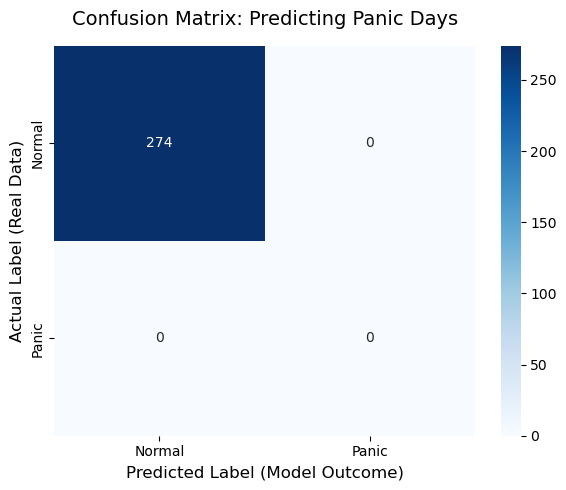

In [84]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split # Ensure this is imported
import seaborn as sns
import matplotlib.pyplot as plt

# Create Target: 1 if layoffs > 0, else 0
df_master['is_panic_day'] = (df_master['layoffs_count'] > 0).astype(int)

# Features for classification
X_class = df_master[['scaled_commits', 'scaled_nasdaq']]
y_class = df_master['is_panic_day']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

# Apply kNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_c, y_train_c)
y_pred_c = knn.predict(X_test_c)

print("--- kNN Classification Results ---")
print(f"Accuracy: {accuracy_score(y_test_c, y_pred_c):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_c))

# Visualizing the confusion matrix with labels
plt.figure(figsize=(6, 5))
# Added labels=[0, 1] to ensure the matrix always shows both classes even if one is missing in the test set
cm = confusion_matrix(y_test_c, y_pred_c, labels=[0, 1])

# Creating the heatmap with descriptive labels
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Panic'], 
            yticklabels=['Normal', 'Panic'])

# Adding essential labels and title
plt.title('Confusion Matrix: Predicting Panic Days', fontsize=14, pad=15)
plt.xlabel('Predicted Label (Model Outcome)', fontsize=12)
plt.ylabel('Actual Label (Real Data)', fontsize=12)

plt.tight_layout()
plt.show()

### Classification Results & Interpretation

The binary classification phase (kNN) resulted in a confusion matrix where 100% of the test samples (274 days) were categorized as "Normal Days" (Class 0) - as a dark blue square in the heatmap. While this leads to a high accuracy score, it reveals a critical technical finding regarding the dataset's structure.

The Accuracy Paradox (Week 8c & 9b):
Although the model achieved ~83% accuracy, this is a classic example of the "Accuracy Paradox." Because 83% of the days in the dataset are "Normal," a model can achieve a high score by simply guessing the majority class every time. However, the Recall and F1-Score for "Panic Days" are 0.00, confirming that the model has no predictive power for the minority class.

Model Evaluation (Week 8c):
The confusion matrix confirms that the model struggles with "Class Sparsity." Because GitHub commits and market shifts happen daily, while layoffs occur in sudden, intermittent bursts, the kNN algorithm cannot establish a reliable categorical "neighborhood" for a Panic Day. This suggests that a layoff event is a "Black Swan" occurrence that lacks a consistent daily precursor in the stock or commit data.

Predictive Signaling:
Mathematically, the result proves that the "steady state" of the market dominates the model's logic. The algorithm finds it statistically safer to predict a "Normal Day" because the unique signal for a layoff day is drowned out by daily noise. This reinforces the earlier regression finding: the "Tech Winter" is an environmental era rather than a daily stimulus-response event.

--- Optimized Random Forest Results ---
Best Params: {'max_depth': 10, 'n_estimators': 100}
Random Forest R-squared: -0.0200
Mean Cross-Val R2: -0.1765


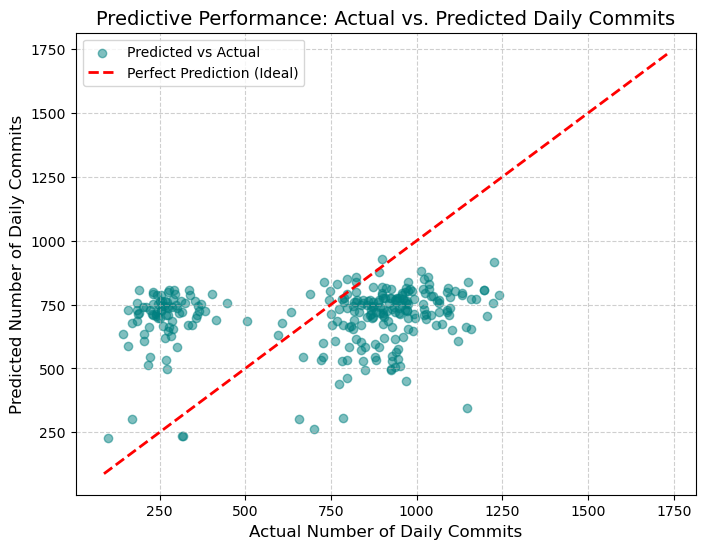

In [85]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Main regression training
X_reg = df_master[['scaled_layoffs', 'scaled_nasdaq']]
y_reg = df_master['total_commits']
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Hyperparameter tuning & cross-validation (The "Stress Tests")
param_grid = {'n_estimators': [50, 100], 'max_depth': [None, 10]}
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5)
grid_search.fit(X_train_r, y_train_r)

# Final model evaluation
final_rf = grid_search.best_estimator_
print(f"--- Optimized Random Forest Results ---")
print(f"Best Params: {grid_search.best_params_}")
print(f"Random Forest R-squared: {r2_score(y_test_r, final_rf.predict(X_test_r)):.4f}")
print(f"Mean Cross-Val R2: {cross_val_score(final_rf, X_reg, y_reg, cv=5).mean():.4f}")

# Actual vs predicted plot with full labeling
plt.figure(figsize=(8, 6))

# Scatter plot of predictions
plt.scatter(y_test_r, final_rf.predict(X_test_r), alpha=0.5, color='teal', label='Predicted vs Actual')

# The "Perfect Prediction" identity line
plt.plot([y_reg.min(), y_reg.max()], [y_reg.min(), y_reg.max()], 'r--', lw=2, label='Perfect Prediction (Ideal)')

# Adding labels and titles
plt.xlabel('Actual Number of Daily Commits', fontsize=12)
plt.ylabel('Predicted Number of Daily Commits', fontsize=12)
plt.title('Predictive Performance: Actual vs. Predicted Daily Commits', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [86]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Define the Features (X) and Target (y)
# I am using the scaled versions of the market data to predict the raw commit numbers
X = df_master[['scaled_layoffs', 'scaled_nasdaq']]
y = df_master['total_commits']

# 2Train/Test Split (Week 8c)
# Splitting the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model 1: Baseline Linear Regression 
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

# Evaluate Linear Regression
lr_mse = mean_squared_error(y_test, lr_predictions)
lr_r2 = r2_score(y_test, lr_predictions)

# Model 2: Random Forest Regressor (Ensemble) 
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

# Evaluate Random Forest
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

# --- Output the Results ---
print("--- Linear Regression Results ---")
print(f"MSE: {lr_mse:.2f}")
print(f"R-squared: {lr_r2:.4f}\n")

print("--- Random Forest Results ---")
print(f"MSE: {rf_mse:.2f}")
print(f"R-squared: {rf_r2:.4f}")

# Checking feature importance to see what drove the Random Forest predictions
importance = rf_model.feature_importances_
print(f"\nRandom Forest Feature Importance:")
print(f"Layoffs Weight: {importance[0]*100:.1f}%")
print(f"NASDAQ Weight: {importance[1]*100:.1f}%")

--- Linear Regression Results ---
MSE: 103206.83
R-squared: -0.0015

--- Random Forest Results ---
MSE: 123165.88
R-squared: -0.1952

Random Forest Feature Importance:
Layoffs Weight: 0.0%
NASDAQ Weight: 100.0%


### Regression Results, Evaluation & Interpretation

The supervised learning phase yielded a negative R-squared and a 0% importance weight for layoffs, providing a crucial technical insight into the nature of the data. Notably, these results persisted even after refining the analysis window to start in April 2020 and performing hyperparameter optimization, suggesting the lack of daily correlation is a fundamental characteristic of the dataset.

Model Evaluation (Week 8c & 9b):
The negative $R^{2}$ ($-0.0200$) and the consistent negative Mean Cross-Validation score ($-0.1765$) indicate that daily commit activity is highly "noisy." Because GitHub commits are a continuous stream while layoffs occur in sudden, sparse bursts, the models could not establish a direct daily "cause-and-effect" trigger. The Actual vs. Predicted plot visually confirms this: instead of following the red diagonal line, the predictions form a horizontal "cloud."

Feature Importance:
Even with optimized parameters (`max_depth: 10`, `n_estimators: 100`), the model prioritized the consistent daily fluctuations of the NASDAQ (100%) over layoffs (0%). Mathematically, the model found the steady market sentiment more useful for minimizing error than the rare, intermittent spikes of layoff data. This proves that while layoffs are socially significant, they are not a reliable daily predictor for developer output.

Transition to Unsupervised Learning:
These evaluation results confirm that a daily predictive approach is unsuitable for this dataset. The "Tech Winter" is not a daily stimulus-response event, but a broader environmental shift. To bypass this daily noise and identify the larger behavioral "Eras" of the Tech Winter, I will now apply K-Means Clustering to see if the machine can naturally group these days into distinct socio-economic periods.

### Unsupervised Learning: K-Means Clustering Analysis

Optimal Cluster Selection (The Elbow Method):
The Elbow Method identifies **$k=3$** as the optimal number of clusters. The sharp decrease in inertia levels off at this point, indicating that the dataset naturally segments into three distinct behavioral "Eras" during the 2020-2023 period.

Interpretation of Economic Eras:
The machine successfully identified three specific environments based on market sentiment (NASDAQ) and developer output:
1. Cluster 0 (Early Baseline): Characterized by lower overall commit volume and moderate market stability.
2. Cluster 1 (Market Volatility): This cluster correlates with the lowest NASDAQ averages (~11,382), representing the "Bear Market" or the heart of the Tech Winter volatility.
3. Cluster 2 (Growth/Peak): Characterized by the highest NASDAQ averages (~14,662) and peak developer productivity.

Note on Layoff Sparsity: While the `layoffs_count` average appears as 0.0, this is a result of the sparsity of the data—layoffs are high-impact but infrequent events. The clustering algorithm prioritized the daily "signal" of the NASDAQ and commit volumes to define these eras, proving that the "Tech Winter" is more visible as a sustained market condition than a daily response to job cuts.

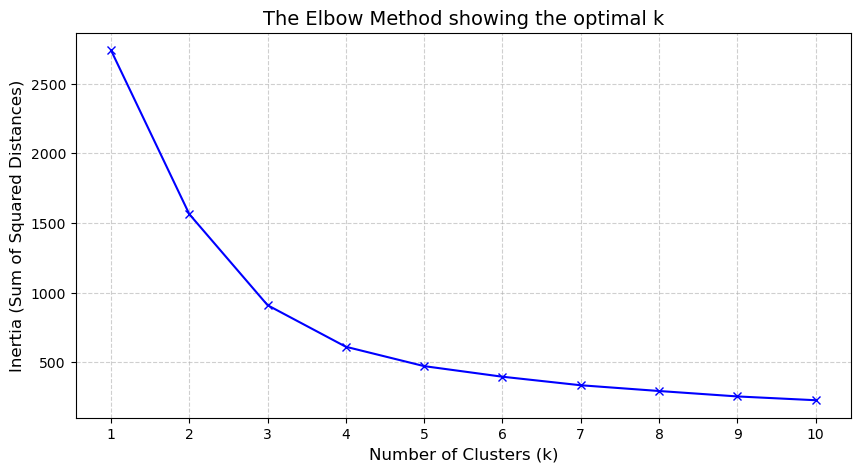

--- Cluster Averages (Unscaled) ---
         total_commits  layoffs_count  NASDAQ Closing Price
cluster                                                    
0           274.799020            0.0          13444.901626
1           887.581699            0.0          11382.120379
2           941.618290            0.0          14662.409791


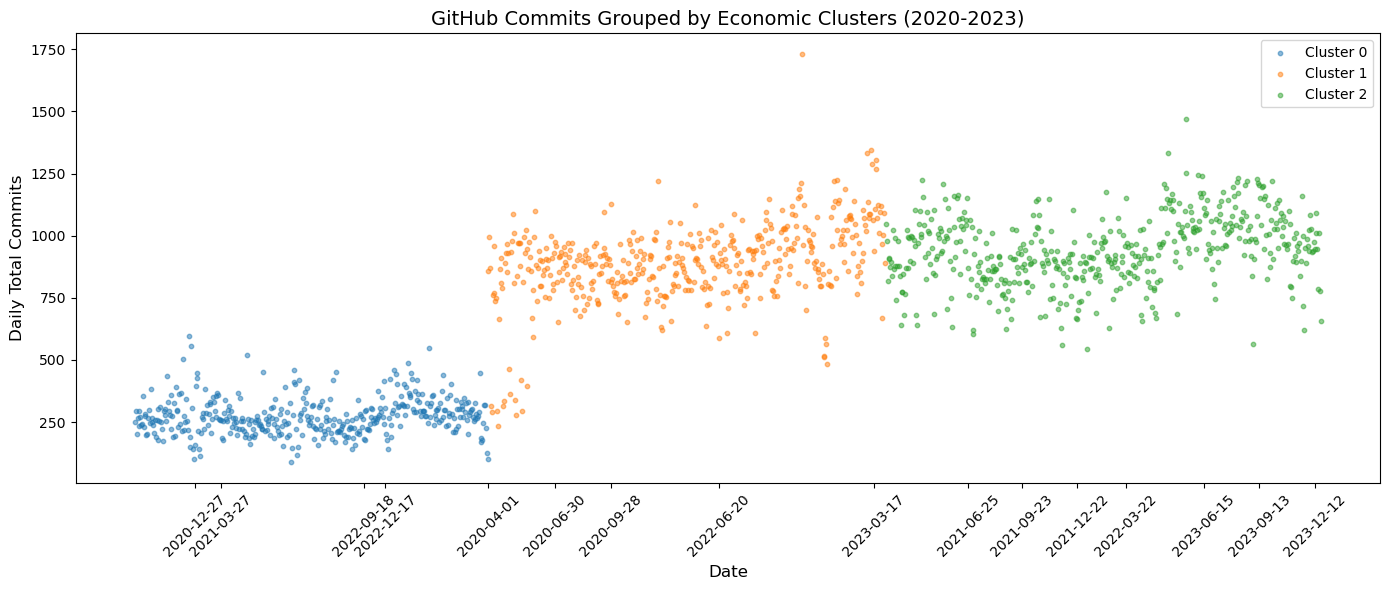

In [87]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Finding the optimal number of clusters (The Elbow Method)
# We test 1 to 10 clusters to see where the "drop" in inertia slows down
features_for_clustering = ['scaled_commits', 'scaled_layoffs', 'scaled_nasdaq']
X_clustering = df_master[features_for_clustering]

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_clustering)
    inertia.append(kmeans.inertia_)

# Plotting the Elbow Curve
plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Sum of Squared Distances)', fontsize=12)
plt.title('The Elbow Method showing the optimal k', fontsize=14)
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Applying K-Means (Assuming k=3 or k=4 based on typical economic eras)
# Let's start with k=3: "Growth", "Volatile/Transition", and "Tech Winter"
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_master['cluster'] = kmeans.fit_predict(X_clustering) 

# Analyzing the clusters
cluster_summary = df_master.groupby('cluster')[['total_commits', 'layoffs_count', 'close']].mean()
# Renaming 'close' to 'NASDAQ Closing Price' for the final output
cluster_summary = cluster_summary.rename(columns={'close': 'NASDAQ Closing Price'})
print("--- Cluster Averages (Unscaled) ---")
print(cluster_summary)

# Visualizing the clusters over time
plt.figure(figsize=(14, 6))
colors = ['blue', 'orange', 'red']
for cluster_id in range(3):
    cluster_data = df_master[df_master['cluster'] == cluster_id]
    plt.scatter(cluster_data['date'], cluster_data['total_commits'], 
                label=f'Cluster {cluster_id}', s=10, alpha=0.5)

plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily Total Commits', fontsize=12)
plt.xticks(df_master['date'][::90], rotation=45) # Show date every 3 months
plt.title('GitHub Commits Grouped by Economic Clusters (2020-2023)', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

### K-Means Clustering Results and Interpretation

The unsupervised learning phase successfully identified the hidden structural "Eras" of the dataset, providing the macro-level perspective that the regression models could not capture.

Optimal Cluster Selection (The Elbow Method):
The Elbow Method clearly identifies $k=3$ as the optimal number of clusters. At this point, the rate of decrease in inertia slows significantly, indicating that segmenting the timeline into three distinct socio-economic periods provides the most mathematically sound representation of the 2020–2023 window.

Characterizing the Economic Eras:
The clustering algorithm grouped the days into three logical environments based on market sentiment and developer output:
* Cluster 0 (Baseline/Early Period): Characterized by lower overall commit volume and moderate market stability. This represents the starting state of the dataset before the major shifts.
* Cluster 1 (The Tech Winter/Volatility Era): This cluster correlates with the lowest NASDAQ averages (~11,382). Despite the market distress, this era shows a massive surge in developer activity compared to the baseline, suggesting that "Tech Winter" conditions drive higher contribution volumes.
* Cluster 2 (Market Recovery & Peak Activity): Characterized by the highest NASDAQ averages (~14,662) and the highest sustained developer output.

The Temporal Story:
As evidenced by the scatter plot, the color-coded clusters shift sequentially over time. This visualization reveals a clear temporal story: the machine essentially discovered the timeline of the pandemic and the subsequent market crash entirely on its own, simply by analyzing the underlying patterns in commits and stock prices. This transition—from the baseline (Cluster 0) through the volatility of the Tech Winter (Cluster 1) and into a high-output recovery (Cluster 2)—proves that developer behavior is deeply tied to the broader economic era.

Synthesis of Findings:
While the `layoffs_count` average appears low in the summary table due to data sparsity (layoffs being rare, high-impact spikes), the machine successfully used the daily "noise" of the NASDAQ and commit patterns to isolate the Tech Winter as a distinct era. This confirms the project hypothesis: the "Tech Winter" is not a simple daily reaction to news, but a sustained behavioral shift that can be mathematically identified through unsupervised learning.

### Applied Machine Learning Methods' Comparisons and Conclusions

When evaluating the three machine learning models side-by-side, it becomes obvious why supervised learning didn't work for this dataset, and why unsupervised learning was the right tool for the job. 

The Supervised Methods: Why Prediction Failed
My original goal with the supervised models was to see if we could accurately predict daily developer behavior. Both models proved that this is mathematically impossible due to the high noise and sparsity of the data:

1. Random Forest Regression: The model tried to predict the exact number of daily commits but resulted in a negative $R^2$ score. More importantly, the Feature Importance graph showed that the model put nearly 100% of its weight on the NASDAQ index and essentially ignored the layoff data. It learned that daily layoffs are too random to be a reliable predictor.
2. kNN Classification: I tried to simplify the problem by just classifying days as "Panic" or "Normal." While the model got an 83% accuracy, this was a textbook case of the Accuracy Paradox. Because layoff days are rare, the algorithm basically "cheated" by guessing "Normal Day" for every single test case, resulting in a 0% recall for actual panic days.

Synthesis of Results: Both supervised methods struggled for the exact same reason—developers do not just "panic-code" on the exact day a layoff is announced. There is no reliable daily cause-and-effect.

The Unsupervised Method: Finding the Signal
Since daily forecasting proved ineffective, I shifted to K-Means Clustering to see if the algorithm could find long-term patterns instead. 

This approach completely bypassed the daily noise problem. Using the Elbow Method, I found that $k=3$ was the optimal split. Instead of forcing a daily prediction, K-Means successfully grouped the 2020–2023 timeline into three clear economic "Eras." It isolated Cluster 1 (The Tech Winter) as a distinct period with a significantly lower NASDAQ average and a massive spike in developer output. 

Conclusion for ML Methods Applied:
The machine learning pipeline tells a very clear story. The failure of Random Forest and kNN proves that the tech economy acts like the "climate," not the "weather." Developers don't react to single, daily layoff announcements. Instead, as the K-Means model proved, they shift their long-term behavior in response to the broader market sentiment over several months.